# Time-Series data and RNNs

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as snss
import pandas as pd
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.axisbelow'] = True
plt.rcParams['figure.dpi'] = 150

In [2]:
# Check available hardware
import torch
if torch.cuda.is_available():
    print(f'GPU is available, using GPU {torch.cuda.get_device_name(0)}')
    device = torch.device('cuda')
elif torch.mps.is_available():
    print(f'Apple Metal Performance Shaders framework is available, using {torch.device("mps")}')
    device = torch.device('mps')
else:
    print(f'Hardware acceleration not available, using CPU')
    device = torch.device('cpu')

GPU is available, using GPU Tesla T4


## Sequential dataset: Sunspots

In [3]:
df = pd.read_csv('~/data10/monthly-sunspots.csv')
df.Month = pd.to_datetime(df.Month)
df.head()

,Month,Sunspots
0,1749-01-01,58.0
1,1749-02-01,62.6
2,1749-03-01,70.0
3,1749-04-01,55.7
4,1749-05-01,85.0


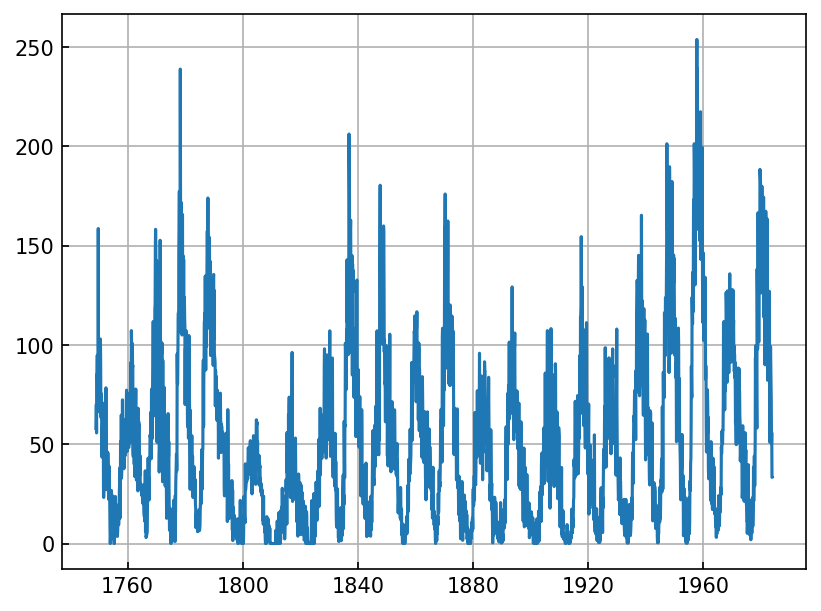

In [4]:
ax = plt.figure().gca()
ax.plot(df.Month, df.Sunspots)

RNN Train Dataset has 2395 sequences
RNN Test Dataset has 375 sequences


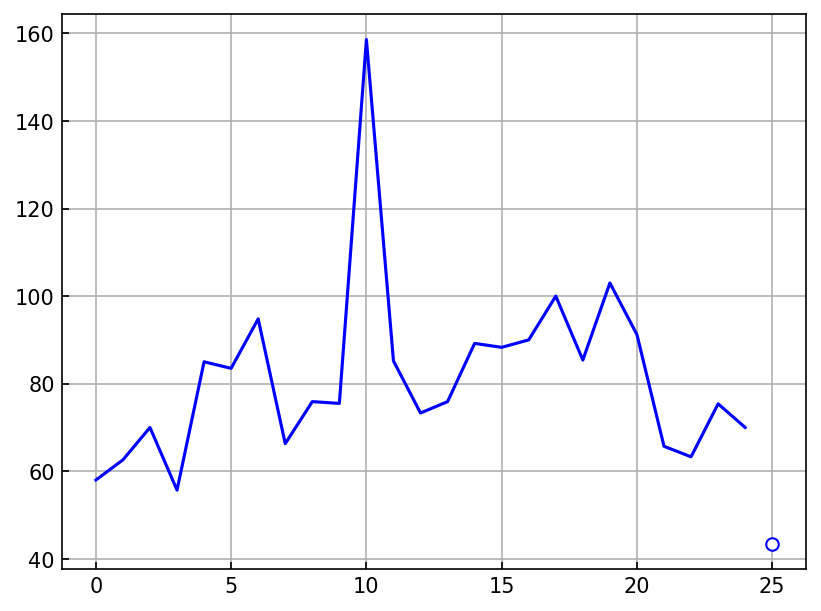

In [5]:
from torch.utils.data import Dataset

class SequenceDataset(Dataset):
    def __init__(self, x, seq_len=25, seq_stride=1):
        self.x = x
        self.seq_len = seq_len
        self.seq_stride = seq_stride

    def __len__(self):
        return len(self.x) - self.seq_len * self.seq_stride

    def __getitem__(self, idx):
        """ Return a sequence of length self.seq_len with stride self.seq_stride
            paired with the next element of the sequence
        """
        slc = slice(idx, idx + (self.seq_len + 1) * self.seq_stride, self.seq_stride)
        x = torch.FloatTensor(self.x[slc])
        return x[:-1], x[-1] # For each element, predict the next element in the sequence

train_seqs = df['Sunspots'].values[:-400, None]
test_seqs = df['Sunspots'].values[-400:, None]

train_val_dataset = SequenceDataset(train_seqs)
print(f"RNN Train Dataset has {len(train_val_dataset)} sequences")

test_dataset = SequenceDataset(test_seqs)
print(f"RNN Test Dataset has {len(test_dataset)} sequences")

x, y = train_val_dataset[0]

ax = plt.figure().gca()
t = np.arange(len(x))
ax.plot(t, x[:, 0], color='blue')
ax.plot(t[-1] + 1, y[0], color='blue', marker='o', markerfacecolor='white')

## A simple baseline for time-series forecasting

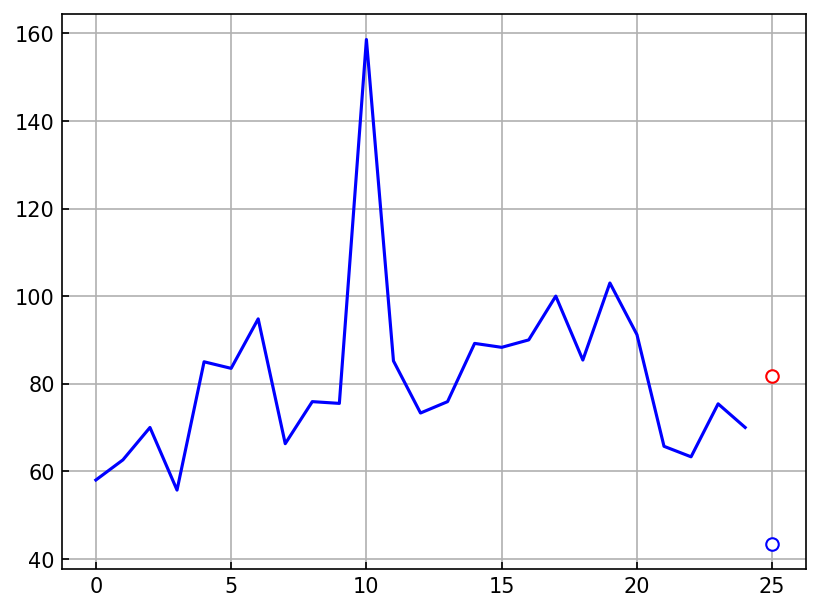

In [8]:
# Simple option - take the average of the lookback-window
x, y = train_val_dataset[0]

ax = plt.figure().gca()
t = np.arange(len(x))
ax.plot(t, x[:, 0], color='blue')
ax.plot(t[-1] + 1, y[0], color='blue', marker='o', markerfacecolor='white')

y_pred = x.mean(dim=0)
ax.plot(t[-1] + 1, y_pred, color='red', marker='o', markerfacecolor='white')

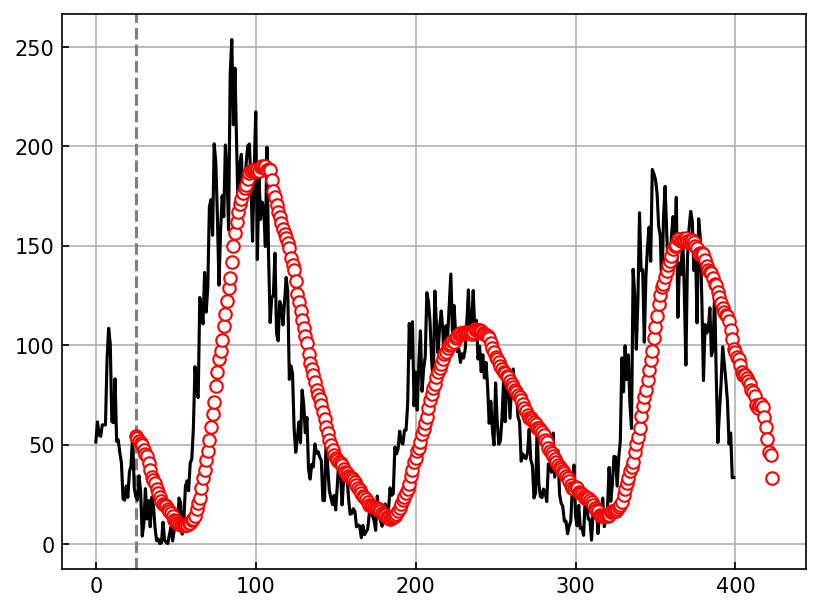

In [9]:
# Simple option - take the average of the lookback-window
# Iterate through the whole test dataset and see how it does

ax = plt.figure().gca()
ax.axvline(test_dataset.seq_len, color='grey', linestyle='--')
ax.plot(test_dataset.x, color='black', label='Inputs')

tt = test_dataset.seq_len
for x, y in test_dataset:
    y_pred = x.mean(dim=0)
    ax.plot(tt, y_pred, color='red', marker='o', markerfacecolor='white')
    tt += 1

[(0.0, 264.0), Text(0.5, 0, 'Months'), Text(0, 0.5, 'Sunspots')]

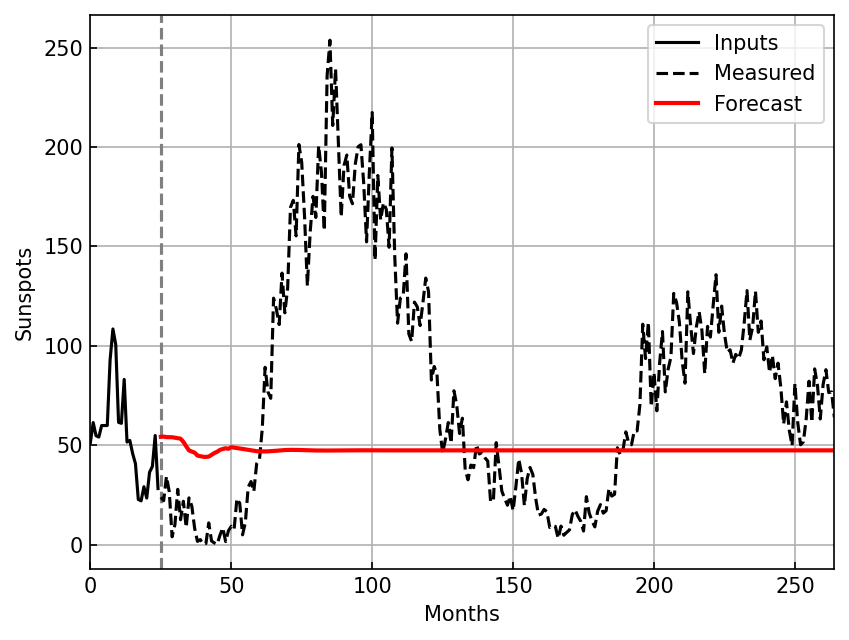

In [13]:
ax = plt.figure().gca()

start_forecast_idx = test_dataset.seq_len
x_in, _ = test_dataset[0]

# What if we want to forecast many months out?
forecast_len = 240

y_pred = []

with torch.no_grad():
    for ii in range(forecast_len):
        y_out = x_in.mean(dim=0)
        y_pred.append(y_out.numpy())
        x_in = torch.concat([x_in[1:], y_out[:, None]])
    y_pred = np.concatenate(y_pred)

ax.axvline(start_forecast_idx, color='grey', linestyle='--')
ax.plot(test_dataset.x[:start_forecast_idx], color='black', label='Inputs')

t = np.arange(y_pred.shape[0]) + start_forecast_idx
ax.plot(t, test_dataset.x[start_forecast_idx:start_forecast_idx+len(y_pred)], 
        color='black', linestyle='--', label='Measured')
ax.plot(t, y_pred, color='red', linewidth=2, label='Forecast')
ax.legend(loc='upper right')

ax.set(
    xlim=[0, t[-1]],
    xlabel='Months',
    ylabel='Sunspots'
)

## A less simple baseline: ARIMA

ARIMA stands for **Autoregressive Integrated Moving Average**.

                               SARIMAX Results                                
Dep. Variable:               Sunspots   No. Observations:                  240
Model:                 ARIMA(1, 0, 2)   Log Likelihood                -975.883
Date:                Mon, 05 Oct 2026   AIC                           1961.766
Time:                        20:18:43   BIC                           1979.170
Sample:                    01-01-1749   HQIC                          1968.779
                         - 12-01-1768                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         50.9085     14.208      3.583      0.000      23.061      78.756
ar.L1          0.9659      0.022     43.832      0.000       0.923       1.009
ma.L1         -0.5154      0.058     -8.934      0.0

/opt/conda/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/conda/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/conda/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


[(0.0, 479.0), Text(0.5, 0, 'Months'), Text(0, 0.5, 'Sunspots')]

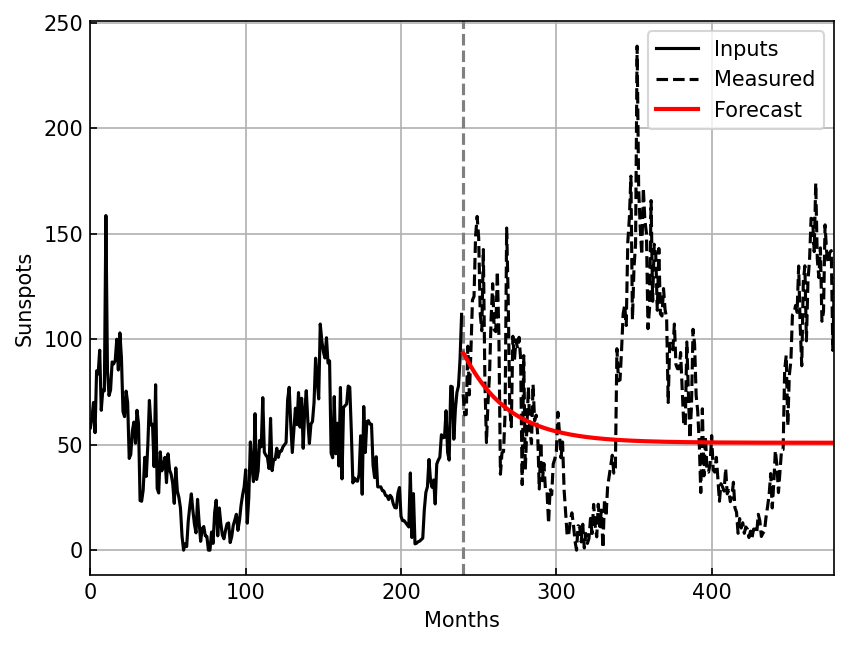

In [33]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

start_idx = 240
forecast_len = 240

x_in = df.iloc[:start_idx].set_index('Month')
model = ARIMA(x_in, order=(1, 0, 2))
# model = SARIMAX(x_in, order=(1, 0, 1), seasonal_order=(1, 1, 1, 132))
model_fitted = model.fit()
print(model_fitted.summary())
y_pred = model_fitted.forecast(steps=forecast_len)

ax = plt.figure().gca()
ax.axvline(start_idx, color='grey', linestyle='--')
ax.plot(df.iloc[:start_idx]['Sunspots'].values, color='black', label='Inputs')

t = np.arange(y_pred.shape[0]) + start_idx
ax.plot(t, df.iloc[start_idx:start_idx+forecast_len]['Sunspots'].values, 
        color='black', linestyle='--', label='Measured')
ax.plot(t, y_pred, color='red', linewidth=2, label='Forecast')
ax.legend(loc='upper right')

ax.set(
    xlim=[0, t[-1]],
    xlabel='Months',
    ylabel='Sunspots'
)

## RNN Training

In [34]:
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import DataLoader, random_split
from tqdm.notebook import trange, tqdm

def train(model, optimizer, loss_func, train_dataset, val_dataset, batch_size=64, num_epochs=10, num_workers=4):
    model = model.to(device)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, num_workers=num_workers, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, num_workers=num_workers, shuffle=False)

    train_loss = []
    train_mad = []
    val_loss = []
    val_mad = []

    pbar_epoch = trange(num_epochs)
    for ii in pbar_epoch:
        model.train()
        train_loss_ = 0.
        train_mad_ = 0.
        for xb, yb in train_loader:
            # Send data to device
            xb = xb.to(device)
            yb = yb.to(device)

            # Make a prediction, compute the loss
            y_pred = model(xb)
            loss = loss_func(y_pred, yb)

            # Backpropagate, apply gradient updates, zero gradients
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            # Logging
            train_loss_ += loss.item() * yb.shape[0]
            train_mad_ += F.l1_loss(y_pred, yb, reduction='sum').item()
            
        train_loss.append(train_loss_ / len(train_loader.dataset))
        train_mad.append(train_mad_ / len(train_loader.dataset))

        model.eval()
        with torch.no_grad():
            val_loss_ = 0.
            val_mad_ = 0.
            for xb, yb in val_loader:
                # Send data to device
                xb = xb.to(device)
                yb = yb.to(device)
                
                # Make a prediction, compute the loss
                y_pred = model(xb)
                loss = loss_func(y_pred, yb)

                # Logging
                val_loss_ += loss.item() * yb.shape[0]
                val_mad_ += F.l1_loss(y_pred, yb, reduction='sum').item()
                
            val_loss.append(val_loss_ / len(val_loader.dataset))
            val_mad.append(val_mad_ / len(val_loader.dataset))

        pbar_epoch.set_postfix(
            epoch=f"{ii+1:03d} / {num_epochs:03d}",
            train_loss=f"{train_loss[-1]:.3f}",
            train_MAD=f"{train_mad[-1]:.3f}",
            val_loss=f"{val_loss[-1]:.3f}",
            val_MAD=f"{val_mad[-1]:.3f}")
        # Consider early stopping
        # Consider learning rate scheduling

    return model, (train_loss, train_mad, val_loss, val_mad)

In [38]:
class RNN_Sequence_Forecast(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(1, 128, num_layers=1, batch_first=True)
        self.linear = nn.Linear(128, 1)
        
    def forward(self, x):
        output, (h_n, c_n) = self.lstm(x)
        output = self.linear(output[:, -1])
        return output

from torch.utils.data import random_split
train_dataset, val_dataset = random_split(train_val_dataset, lengths=[0.8, 0.2])

rnn_model = RNN_Sequence_Forecast().to(device)
loss = nn.MSELoss()
optimizer = torch.optim.Adam(rnn_model.parameters(), lr=1e-3)
rnn_model, rnn_stats = train(rnn_model, optimizer, loss, train_dataset, val_dataset, num_epochs=50)

  0%|          | 0/50 [00:00<?, ?it/s]

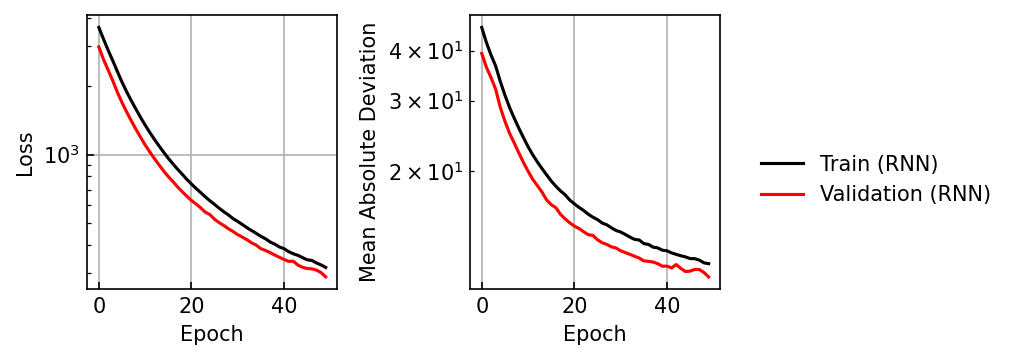

In [39]:
fig, ax = plt.subplots(1, 2, sharex=True, figsize=(5, 2.5))

ax[0].plot(rnn_stats[0], color='black', label='Train (RNN)')
ax[0].plot(rnn_stats[2], color='red', label='Validation (RNN)')
ax[0].set(xlabel='Epoch', ylabel='Loss', yscale='log')

ax[1].plot(rnn_stats[1], color='black', label='Train (RNN)')
ax[1].plot(rnn_stats[3], color='red', label='Validation (RNN)')
ax[1].set(xlabel='Epoch', ylabel='Mean Absolute Deviation', yscale='log')

fig.legend(*ax[1].get_legend_handles_labels(), 
        loc='center left', bbox_to_anchor=[1, 0.5], framealpha=0)

plt.tight_layout()

[(0.0, 264.0), Text(0.5, 0, 'Months'), Text(0, 0.5, 'Sunspots')]

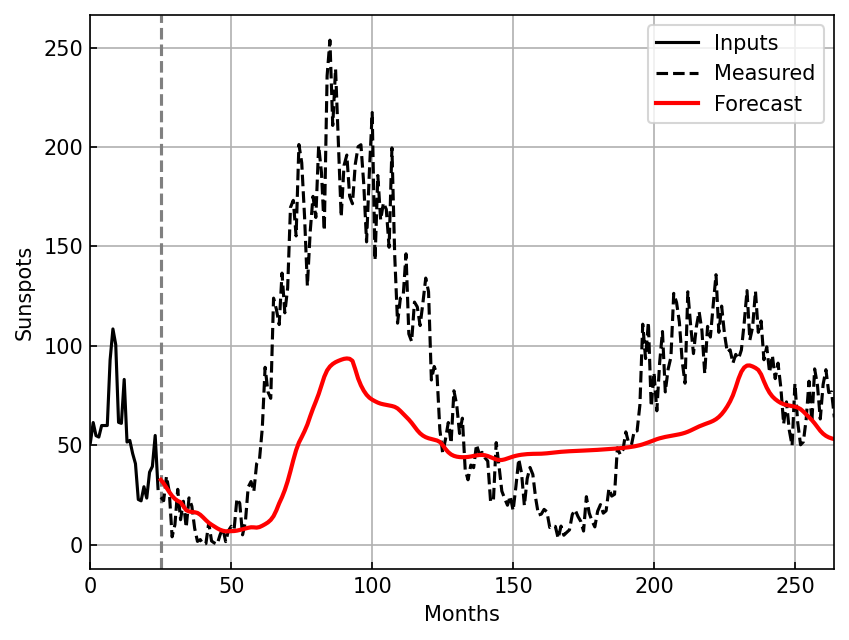

In [40]:
ax = plt.figure().gca()

start_forecast_idx = test_dataset.seq_len
x_in, _ = test_dataset[0]
forecast_len = 240
with torch.no_grad():
    x_in = torch.FloatTensor(x_in).to(device)
    y_rnn = []
    for ii in range(forecast_len):
        y_out = rnn_model(x_in[None])
        y_rnn.append(y_out.cpu().numpy()[0])

        x_in = torch.concat([x_in[1:], y_out])

    y_rnn = np.array(y_rnn)

ax.axvline(start_forecast_idx, color='grey', linestyle='--')

ax.plot(test_dataset.x[:start_forecast_idx], color='black', label='Inputs')
t = np.arange(y_rnn.shape[0]) + start_forecast_idx
ax.plot(t, test_dataset.x[start_forecast_idx:start_forecast_idx+len(y_rnn)], 
        color='black', linestyle='--', label='Measured')
ax.plot(t, y_rnn, color='red', linewidth=2, label='Forecast')
ax.legend(loc='upper right')

ax.set(
    xlim=[0, t[-1]],
    xlabel='Months',
    ylabel='Sunspots'
)

In [31]:
test_dataset.seq_len

20